# **Global AI, ML & Data Science Salaries**

# **EDA - Exploratory Data Analysis**

Este notebook tem como objetivo realizar as análises, entendendo os dados, padrões, testando hipóteses, respondendo perguntas, criando gráficos e gerando insights.

### Fonte dos Dados

Os dados utilizados neste projeto são derivados do dataset público **"Global Salaries in AI, ML & Data Science"**, originalmente disponibilizado no Kaggle.

In [46]:
# Importando bibliotecas
import pandas as pd
import numpy as np
import streamlit as st
import plotly.express as px
import matplotlib.pyplot as plt

**⚠️ IMPORTANTE:** Colunas novas, criadas na etapa de ETL, que serão utilizadas para análises e/ou visualizações: **remote_ratio_pt**, **experience_level_pt**, **employment_type_pt**, **company_size_pt**, **salary_usd_k**, **residence_iso3**

⚠️ Para a Análise Exploratória vamos utilizar o csv limpo, salvo como **salaries_clean.csv**!

In [47]:
# Carregando o conjunto de dados
df = pd.read_csv('../data/salaries_clean.csv')

### Como os salários na área de Dados variam globalmente de acordo com cargo, experiência, tipo de trabalho, empresa e localização?

## 📌 **Análise Inicial**

Nesta etapa, utilizou-se estatística descritiva para variáveis categóricas, com foco em identificar o perfil predominante da amostra. O objetivo é compreender o perfil geral dos profissionais e das empresas presentes no DataFrame, analisando a distribuição das principais variáveis categóricas, como nível de experiência, tipo de contrato, cargo, localização, salário e regime de trabalho.

In [48]:
# Análise descritiva das colunas categóricas
df.describe(include='object')

,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size,remote_ratio_pt,experience_level_pt,employment_type_pt,company_size_pt,residence_iso3
count,57194,57194,57194,57194,57194,57194,57194,57194,57194,57194,57194,57194
unique,4,4,253,25,91,82,3,3,4,4,3,91
top,SE,FT,Data Scientist,USD,US,US,M,Presencial,Sênior,Tempo Integral,Média,USA
freq,33865,56975,9706,54467,51857,51909,55025,44355,33865,56975,55025,51857


In [49]:
# Quantidade de Sêniors
df['experience_level_pt'].loc[df['experience_level_pt']=="Sênior"].value_counts()

experience_level_pt
Sênior    33865
Name: count, dtype: int64

In [50]:
# Verificando o cargo mais frequente no DataFrame e sua quantidade
cargo_mais_frequente = df['job_title'].value_counts().idxmax()
quantidade = df['job_title'].value_counts().max()

print('Cargo que aparece com mais frequência no DataFrame:', cargo_mais_frequente)
print('Aparece', quantidade, 'vezes no dataset.')

Cargo que aparece com mais frequência no DataFrame: Data Scientist
Aparece 9706 vezes no dataset.


### Principais observações iniciais:

- A maioria dos funcionários atuam como Sênior.
- O tipo de contrato mais frequente é o tipo Tempo Integral.
- O cargo de Data Scientist (Cientista de Dados) é o mais frequente na amostra.
- Os Estados Unidos é o país onde está situado a maioria dos profissionais da amostra.
- A maior parte das empresas estão situadas nos Estados Unidos.
- O regime de trabalho presencial é o mais comum.
- A maioria das empresas são de médio porte.

In [51]:
total_registros = df.shape[0]
total_registros

57194

In [52]:
ano_minimo = df['work_year'].min()
ano_maximo = df['work_year'].max()
print('Ano mínimo no conjunto de dados: ', ano_minimo)
print('Ano máximo no conjunto de dados: ', ano_maximo)

Ano mínimo no conjunto de dados:  2020
Ano máximo no conjunto de dados:  2024


In [53]:
anos_ordenados = df['work_year'].sort_values().unique()
print('Anos presentes no conjunto de dados: ', anos_ordenados)

Anos presentes no conjunto de dados:  [2020 2021 2022 2023 2024]


🎯 O DataFrame possui dados de salários dentro de um período de 4 anos, do ano 2020 até o ano 2024.

## 📌 **Distribuição Salarial**

### Qual é o panorama geral dos salários na área de Dados?

In [54]:
maior_salario = df['salary_usd_k'].max()
print('Maior salário anual em USD:', maior_salario)

menor_salario = df['salary_usd_k'].min()
print('Menor salário anual em USD:', menor_salario)

Maior salário anual em USD: 800.0
Menor salário anual em USD: 15.0


🎯 Observa-se uma grande dispersão salarial, com valores variando de 15.000 a 800.000 mil USD anuais, indicando forte heterogeneidade no mercado global de dados, possivelmente influenciada por nível de experiência, cargo, localização e tipo de contrato.

In [55]:
media_salario = df['salary_usd_k'].mean().round(2)
print('Média salarial anual: ', media_salario)

Média salarial anual:  159.22


In [56]:
mediana_salario = df['salary_usd_k'].median()
print('Mediana salarial anual: ', mediana_salario)

Mediana salarial anual:  149.04


🎯 A média salarial anual é de aproximadamente 159 mil USD, enquanto a mediana se mostra inferior a esse valor, sugerindo uma distribuição assimétrica. Esse comportamento indica que salários mais elevados podem estar influenciando a média.

## 📌 **Cargos mais bem remunerados**

### Quais cargos na área de Dados apresentam as maiores médias salariais?

In [57]:
# Calculo para saber os top 10 cargos com maiores médias salariais anuais
cargos_maiores_medias_salarias = df.groupby('job_title')['salary_usd_k'].mean().sort_values(ascending=False).head(10)
print('Top 10 cargos que apresentam as maiores médias salariais:', cargos_maiores_medias_salarias)

Top 10 cargos que apresentam as maiores médias salariais: job_title
Analytics Engineering Manager            399.880000
Data Science Tech Lead                   375.000000
Applied AI ML Lead                       292.500000
Head of Machine Learning                 288.701000
Engineering Manager                      262.525616
Machine Learning Performance Engineer    262.500000
AWS Data Architect                       258.000000
Head of AI                               250.828571
Cloud Data Architect                     250.000000
Machine Learning Model Engineer          245.625000
Name: salary_usd_k, dtype: float64


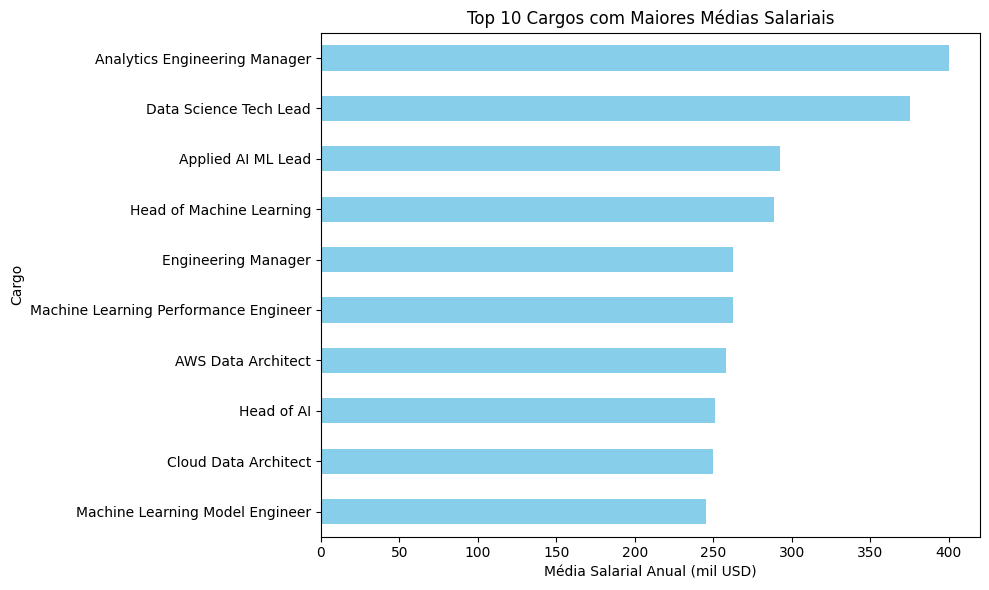

<function matplotlib.pyplot.show(close=None, block=None)>

In [58]:
# Comando para mostrar o gráfico plotado com matplotlib em notebooks logo abaixo do código
%matplotlib inline 

plt.figure(figsize=(10,6))

cargos_maiores_medias_salarias.sort_values().plot(kind='barh', color='skyblue')

plt.xlabel('Média Salarial Anual (mil USD)')
plt.ylabel('Cargo')
plt.title('Top 10 Cargos com Maiores Médias Salariais')
plt.tight_layout()
plt.show()

plt.show

🎯 É possível observar diferenças salariais significativas entre os cargos na área de Dados. Os resultados indicam que o nível de experiência influencia fortemente a remuneração, já que os três cargos com maiores médias são posições de gerência ou liderança, possivelmente correspondendo a profissionais seniors.

Esse insight permite compreender quais funções são mais competitivas em termos de remuneração e pode auxiliar profissionais e recrutadores na tomada de decisões estratégicas.

É importante destacar que a média salarial pode ser influenciada por outliers, especialmente em cargos com poucos registros.

## 📌 **Experiência X Salário**

### Como o nível de experiência influencia a média salarial na área de Dados?

In [59]:
# Cálculo da média salarial anual por nível de experiência
media_salario_experiencia = df.groupby('experience_level_pt')['salary_usd_k'].mean().round(2)
media_salario_experiencia.sort_values(ascending=False)

experience_level_pt
Executivo    202.29
Sênior       173.85
Pleno        143.83
Júnior       104.45
Name: salary_usd_k, dtype: float64

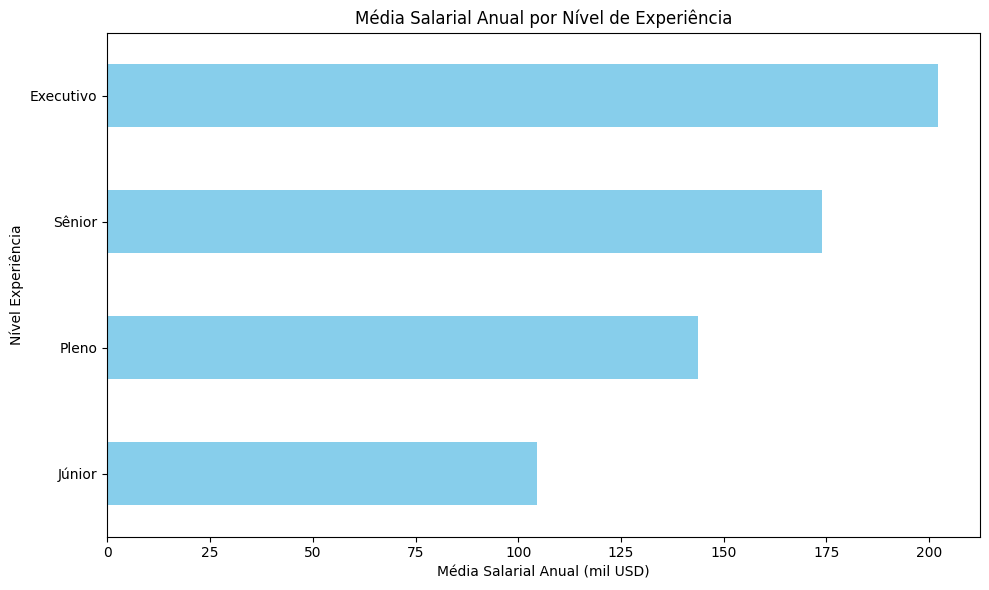

<function matplotlib.pyplot.show(close=None, block=None)>

In [60]:
# Comando para mostrar o gráfico plotado com matplotlib em notebooks logo abaixo do código
%matplotlib inline 

plt.figure(figsize=(10,6))

media_salario_experiencia.sort_values().plot(kind='barh', color='skyblue')

plt.xlabel('Média Salarial Anual (mil USD)')
plt.ylabel('Nível Experiência')
plt.title('Média Salarial Anual por Nível de Experiência')
plt.tight_layout()
plt.show()

plt.show

🎯 O DataFrame evidencia que profissionais com mais experiência tendem a receber salários mais altos, seguindo a lógica Júnior, Pleno e Sênior.

Os cargos executivos apresentam remuneração superior à dos Sêniors. Já o aumento salarial do Júnior para o Pleno é significativo, enquanto do Pleno para o Sênior é menor, indicando uma valorização mais acentuada nos níveis mais elevados.

In [61]:
df['experience_level_pt'].loc[df['experience_level_pt']=="Executivo"].value_counts()

experience_level_pt
Executivo    1196
Name: count, dtype: int64

## 📌 **Tipo de Trabalho**

### Qual é a distribuição dos tipos de trabalho (remoto, híbrido e presencial) na área de Dados?

(np.float64(-1.0999999797829867),
 np.float64(1.0999998975731353),
 np.float64(-1.099999933882001),
 np.float64(1.099999996851524))

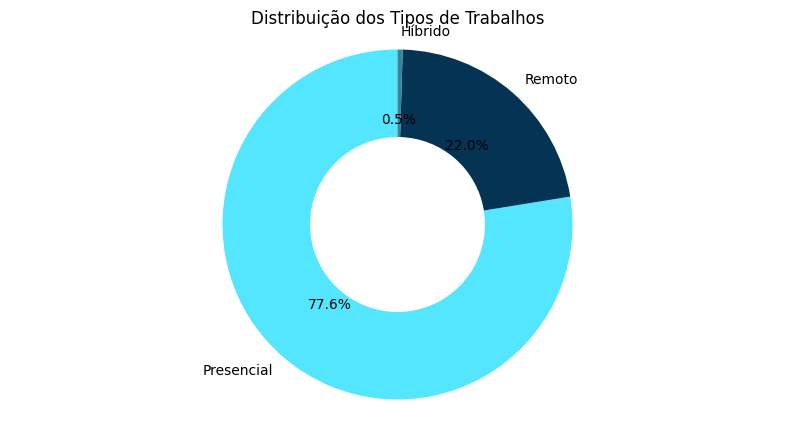

In [62]:
# Comando para mostrar o gráfico plotado com matplotlib em notebooks logo abaixo do código
%matplotlib inline 

contagem_tipo_trabalho = df['remote_ratio_pt'].value_counts(ascending=False).reset_index()

plt.figure(figsize=(10,5))
plt.pie(
    contagem_tipo_trabalho['count'], # Coluna count gerada pelo value_counts()
    labels=contagem_tipo_trabalho['remote_ratio_pt'],
    colors = ["#54E5FF", "#043353", "#368497"], #rgb
    autopct='%1.1f%%', 
    startangle=90,
    wedgeprops={'width': 0.5}
)

# Adiciona título e garante que o círculo seja redondo
plt.title('Distribuição dos Tipos de Trabalhos')
plt.axis('equal')  # Garante que o gráfico seja um círculo perfeito

🎯 A análise da distribuição dos tipos de trabalho indica que o regime presencial ainda representa a maior parcela dos registros na base analisada. No entanto, observa-se uma participação relevante dos modelos remoto e híbrido, especialmente em determinados períodos. Essa variação pode estar associada ao contexto da pandemia de COVID-19.

## 📌 **Empresa X Salário**

### O tamanho da empresa está associado a diferenças na média salarial?

In [63]:
media_salario_tamanho_empresa = df.groupby('company_size')['salary_usd_k'].mean().round(2).sort_values(ascending=False)
media_salario_tamanho_empresa

company_size
M    159.72
L    152.62
S     87.67
Name: salary_usd_k, dtype: float64

🎯 A análise da média salarial por tamanho da empresa indica que existem diferenças de remuneração entre os portes organizacionais. No entanto, não se observa uma relação direta em que empresas de maior porte apresentem necessariamente as maiores médias salariais.

No conjunto de dados analisado, as empresas de médio porte apresentam a maior média salarial. Esse resultado pode estar relacionado à maior representatividade desse porte na base de dados, o que pode influenciar os valores médios observados. Assim, os resultados sugerem uma tendência de variação salarial conforme o tamanho da empresa, sem evidência de uma relação causal direta.

## 📌 **Análise Geográfica do cargo mais frequente (Data Scientist)**

### Como o salário médio de Cientistas de Dados varia entre diferentes países?

In [64]:
# Média salarial anual por país do cargo Cientista de Dados
salario_medio_cientistas_dados = df[df['job_title'] == 'Data Scientist'].groupby('employee_residence')['salary_usd_k'].mean().round(2)
salario_medio_cientistas_dados.sort_values(ascending=False).head(10)

employee_residence
US    165.21
MX    163.46
NZ    154.48
CH    152.26
CA    146.76
EG    142.38
SG    119.06
DO    110.00
IT    108.92
AU    108.16
Name: salary_usd_k, dtype: float64

In [65]:
# Calcular média salarial por país (iso3)
df_data_scientist = df[df['job_title'] == 'Data Scientist']

# Calcular média salarial anual por país (iso3)
media_data_scientist_pais = (
    df_data_scientist.groupby('residence_iso3')['salary_usd_k']
    .mean()
    .reset_index()
)

media_data_scientist_pais = media_data_scientist_pais.sort_values(by='salary_usd_k', ascending=False)
media_data_scientist_pais

,residence_iso3,salary_usd_k
48,USA,165.208365
31,MEX,163.457143
35,NZL,154.475750
7,CHE,152.256667
6,CAN,146.759377
14,EGY,142.380000
42,SGP,119.059000
11,DOM,110.000000
25,ITA,108.921300
2,AUS,108.161286


In [66]:
# Gerar o mapa
# Gradiente personalizado salário baixo → alto
custom_scale = [
    '#f7fbff',
    '#c6dbef',  
    '#6baed6',  
    '#2171b5', 
    '#08306b'   
]

fig = px.choropleth(media_data_scientist_pais,
                    locations='residence_iso3',
                    color='salary_usd_k',
                    color_continuous_scale=custom_scale,
                    title='Salário médio de Cientista de Dados por país',
                    labels={'salary_usd_k': 'Salário médio (mil USD)', 'residence_iso3': 'País'})

fig.show()

In [67]:
# df_dashboard = df com as colunas necessárias para o app.py
df_dashboard = df[[
    'work_year',
    'experience_level_pt',
    'employment_type_pt',
    'job_title',
    'salary_in_usd',
    'salary_usd_k',
    'company_size_pt',
    'remote_ratio_pt',
    'residence_iso3'
]]

df_dashboard.to_csv('../data/salaries_dashboard.csv', index=False)